<a href="https://colab.research.google.com/github/manojmulammagari/Fashion-Vision-PyTorch/blob/main/cnn_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 25.9 MB/s eta 0:00:00


In [3]:
import optuna
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [4]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [5]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Define data augmentations for the training dataset
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor() # Automatically scales pixels to 0-1
])

# Define transforms for the testing dataset
test_transform = transforms.Compose([
    transforms.ToTensor()
])

# Automatically download and load Fashion-MNIST
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.69MB/s]

Training dataset size: 60000
Testing dataset size: 10000


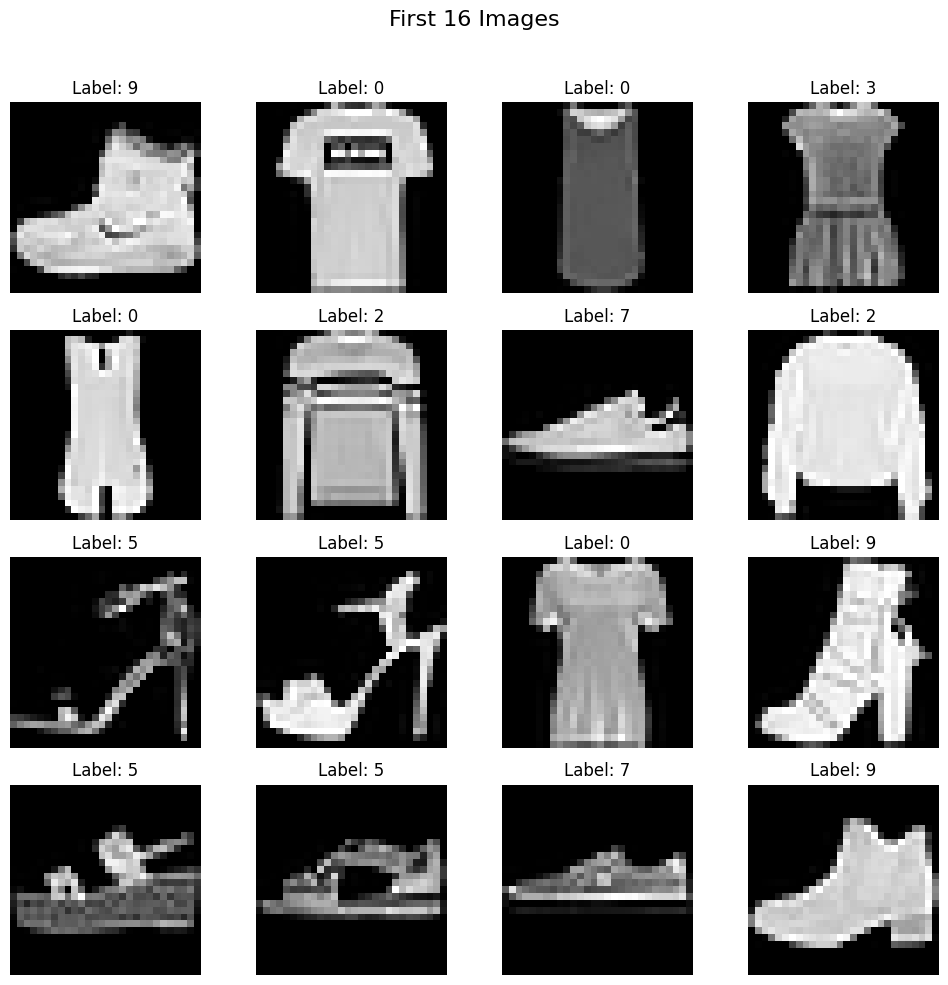

In [9]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images directly from PyTorch dataset
for i, ax in enumerate(axes.flat):
    img = train_dataset.data[i].numpy()
    label = train_dataset.targets[i].item()

    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Label: {label}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Define the dynamic CNN model class
class DynamicCNN(nn.Module):
    def __init__(self, num_conv_layers, num_filters, kernel_size, num_fc_layers, fc_layer_size, dropout_rate):
        super(DynamicCNN, self).__init__()
        layers = []
        in_channels = 1  # Grayscale images have 1 input channel

        # Convolutional layers
        for _ in range(num_conv_layers):
            layers.append(nn.Conv2d(in_channels, num_filters, kernel_size=kernel_size, padding='same'))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm2d(num_filters))
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            in_channels = num_filters  # Update input channels for the next layer

        self.features = nn.Sequential(*layers)




        # Fully connected layers
        fc_layers = [nn.Flatten()]
        input_size = num_filters * (28 // (2 ** num_conv_layers)) ** 2
        for _ in range(num_fc_layers):
            fc_layers.append(nn.Linear(input_size, fc_layer_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            input_size = fc_layer_size
        fc_layers.append(nn.Linear(input_size, 10))  # Final layer for 10 classes

        self.classifier = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [ ]:
# Define the objective function for Optuna
def objective(trial):
    # Hyperparameters to tune
    num_conv_layers = trial.suggest_int('num_conv_layers', 1, 3)
    num_filters = trial.suggest_categorical('num_filters', [16, 32, 64, 128])
    kernel_size = trial.suggest_categorical('kernel_size', [3, 5])
    num_fc_layers = trial.suggest_int('num_fc_layers', 1, 3)
    fc_layer_size = trial.suggest_categorical('fc_layer_size', [64, 128, 256])
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.2, 0.5)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-2)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
    optimizer_name = trial.suggest_categorical('optimizer', ['SGD', 'Adam', 'RMSprop'])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    num_epochs = trial.suggest_int('num_epochs', 10, 30)

    # Model
    model = DynamicCNN(num_conv_layers, num_filters, kernel_size, num_fc_layers, fc_layer_size, dropout_rate).to(device)

    # Data
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Optimizer
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

    # Validation loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = correct / total
    return accuracy

In [ ]:
# Run the Optuna study
pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction='maximize', pruner=pruner)
study.optimize(objective, n_trials=50)  # Run 50 trials

[I 2025-01-24 10:48:25,224] A new study created in memory with name: no-name-985c4d89-ff51-4428-82c6-06e9a87b2f7b
<ipython-input-15-aa1058b9f892>:9: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.2, 0.5)
<ipython-input-15-aa1058b9f892>:10: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-2)
<ipython-input-15-aa1058b9f892>:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('lea

In [ ]:
# Print the best hyperparameters and accuracy
print("Best hyperparameters:", study.best_params)
print("Best accuracy:", study.best_value)